In [1]:
import numpy as np
from qiskit_aer import AerSimulator

backend = AerSimulator()

print(backend.name)

aer_simulator


>>> Observable: ['IIIIIIZZ', 'IIIIIZZI', 'IIIIZZII', 'IIIZZIII', 'IIZZIIII', 'IZZIIIII',
 'ZZIIIIII']
>>> Parameters: ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])


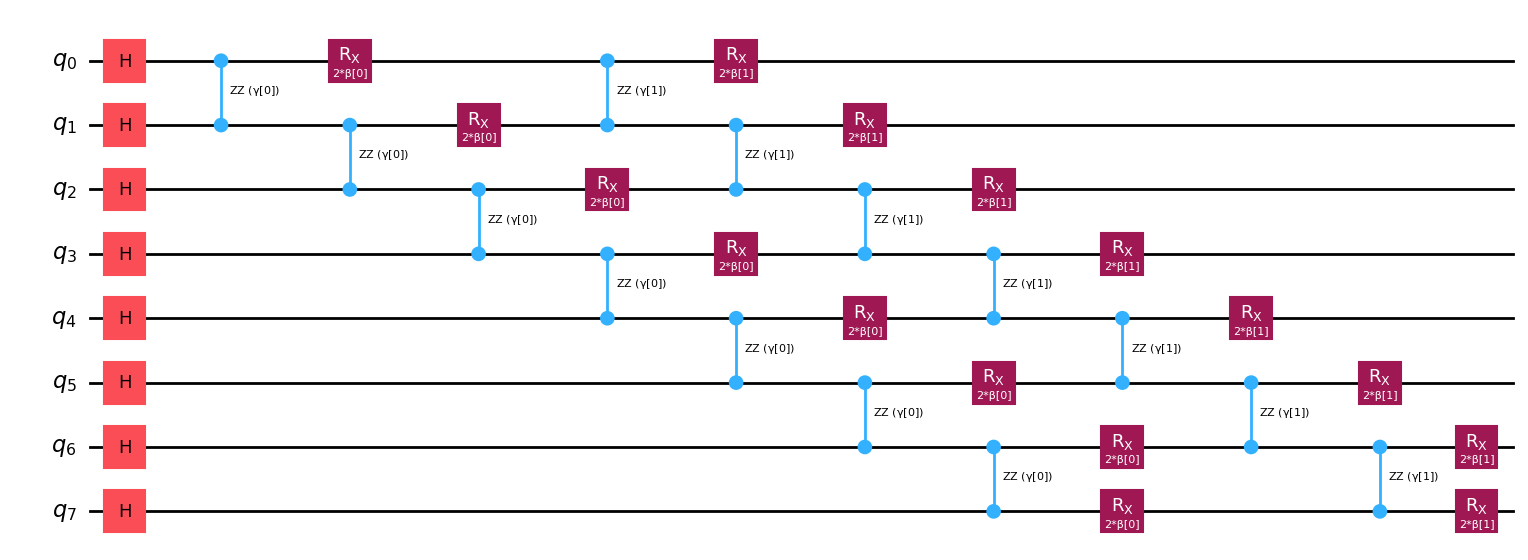

In [2]:
from qiskit.primitives.containers.observables_array import ObservablesArray
from qiskit.circuit.library import qaoa_ansatz, PauliEvolutionGate, PauliProductRotationGate
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp, Pauli
from itertools import product
num_qubits = 8
entanglement = [tuple(edge) for edge in zip(range(num_qubits-1), range(1,num_qubits))]
observable = SparsePauliOp.from_sparse_list(
    [("ZZ", [i, j], 0.5) for i, j in entanglement]#+[("ZZ", [2,4], 0.5)]
    ,
    num_qubits=num_qubits,
)

circuit = qaoa_ansatz(observable, reps=2)
# the circuit is parametrized, so we will define the parameter values for execution
param_values = [0.1, 0.2, 0.3, 0.4]

pauli_strings = ["".join(tu) for tu in product(*(["XYZI"]*8))]
pauli_strings=pauli_strings[:-1]
pauli_gates = [PauliProductRotationGate(Pauli(pauli_string),Parameter("A"), label="$R_{"+pauli_string[::-1]+"}$") for pauli_string in pauli_strings]
pauli_ops = [SparsePauliOp(pauli_string, -0.5j) for pauli_string in pauli_strings]
# circuit.append(pauli_gates[42],list(range(8)))
commutator_list = [(observable @ op - op @ observable).simplify() for op in pauli_ops]
sec_commutator_list = [(op2 @ op1 - op1 @ op2).simplify()
                       for op1, op2 in zip(pauli_ops, commutator_list)]

print(f">>> Observable: {observable.paulis}")
print(f">>> Parameters: {circuit.parameters}")

circuit.draw("mpl")

In [33]:
commutator_op_sizes = np.array([op.size for op in commutator_list])
temp_comm = np.abs(np.array([op.to_list()[0][1] for op in commutator_list]))
temp1 = np.argwhere(np.logical_and(commutator_op_sizes <= 1, temp_comm<0.01))[:,0]
temp2 = np.argwhere(commutator_op_sizes <= 1)[:,0]
print(len(temp1), temp1)
print(len(temp2))
print(temp_comm)
print(np.delete(temp_comm, temp1))
print(commutator_list[-1])
print(pauli_ops[-1])
pauli_ops[-1].to_list()[0][0]

511 [    0     1     4     5    16    17    20    21    64    65    68    69
    80    81    84    85   256   257   260   261   272   273   276   277
   320   321   324   325   336   337   340   341  1024  1025  1028  1029
  1040  1041  1044  1045  1088  1089  1092  1093  1104  1105  1108  1109
  1280  1281  1284  1285  1296  1297  1300  1301  1344  1345  1348  1349
  1360  1361  1364  1365  4096  4097  4100  4101  4112  4113  4116  4117
  4160  4161  4164  4165  4176  4177  4180  4181  4352  4353  4356  4357
  4368  4369  4372  4373  4416  4417  4420  4421  4432  4433  4436  4437
  5120  5121  5124  5125  5136  5137  5140  5141  5184  5185  5188  5189
  5200  5201  5204  5205  5376  5377  5380  5381  5392  5393  5396  5397
  5440  5441  5444  5445  5456  5457  5460  5461 16384 16385 16388 16389
 16400 16401 16404 16405 16448 16449 16452 16453 16464 16465 16468 16469
 16640 16641 16644 16645 16656 16657 16660 16661 16704 16705 16708 16709
 16720 16721 16724 16725 17408 17409 17412 1741

'IIIIIIIZ'

>>> Circuit ops (ISA): OrderedDict({'rx': 16, 'rzz': 14, 'h': 8})


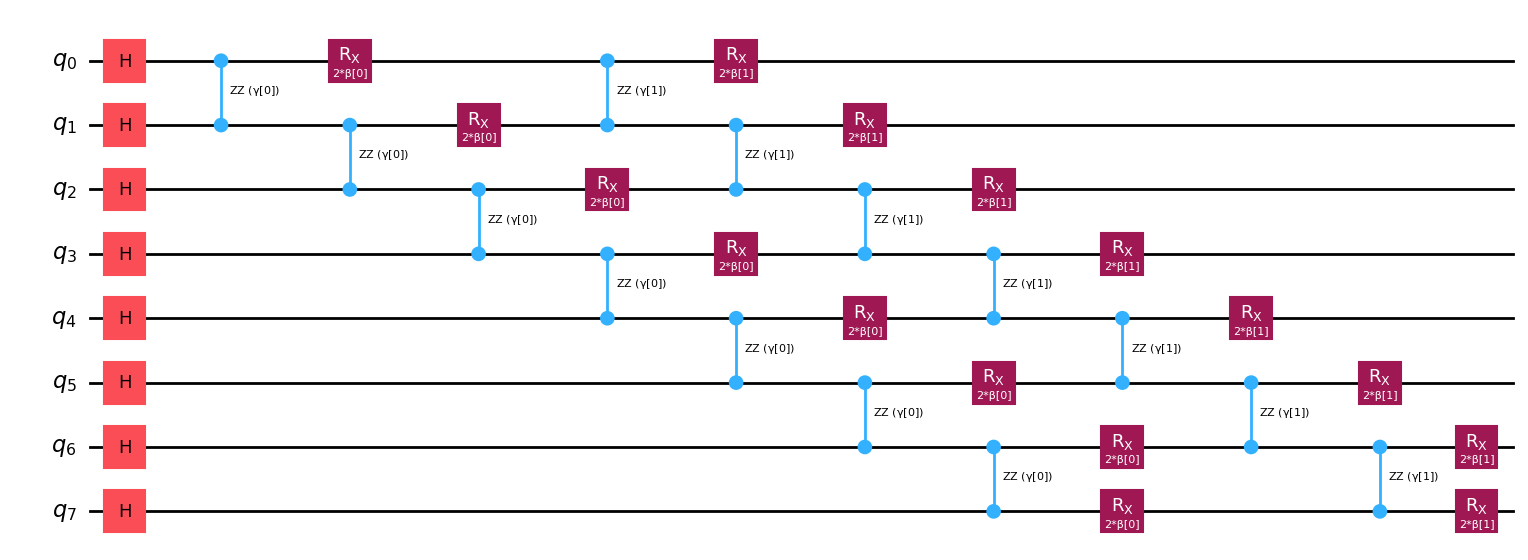

In [4]:
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(circuit)
isa_observable = observable.apply_layout(isa_circuit.layout)
print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")
isa_circuit.draw("mpl")

In [5]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [6]:
job = estimator.run([(isa_circuit, isa_observable, np.array([param_values,param_values]))])
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: d8d5de5b-d683-43a1-8c9b-6f755d19b8a5
>>> Job Status: JobStatus.RUNNING


In [7]:
result = job.result()
print(f">>> {result}")
print(f">>> {result[0]}")
print(f"  > Expectation value: {result[0].data.evs}")
print(f"  > Metadata: {result[0].metadata}")

>>> PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(2,), dtype=float64>), stds=np.ndarray(<shape=(2,), dtype=float64>), shape=(2,)), metadata={'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}})], metadata={'version': 2})
>>> PubResult(data=DataBin(evs=np.ndarray(<shape=(2,), dtype=float64>), stds=np.ndarray(<shape=(2,), dtype=float64>), shape=(2,)), metadata={'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}})
  > Expectation value: [1.53955078 1.53027344]
  > Metadata: {'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}}


In [8]:
from solver.circuits import HardwareAdaptAnsatz23
from qiskit import QuantumCircuit
test = HardwareAdaptAnsatz23(8)
test_gate = test.gate_pool[66]
print(test_gate(Parameter("A")).label)
print(test_gate((Parameter("A"))).name)

$R_{XXXXYXXZ}$
pauli_product_rotation


$R_{XXXXYXXZ}$
pauli_product_rotation


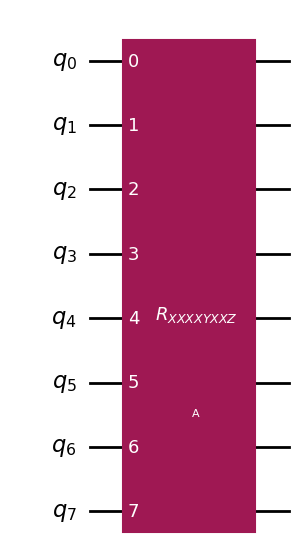

In [9]:
qc = QuantumCircuit(8)
test_gate = test.gate_pool[66](Parameter("A"))
qc.append(test_gate,list(range(8)))
isa_qc = pm.run(qc)
print(test_gate.label)
print(test_gate.name)
qc.draw("mpl")

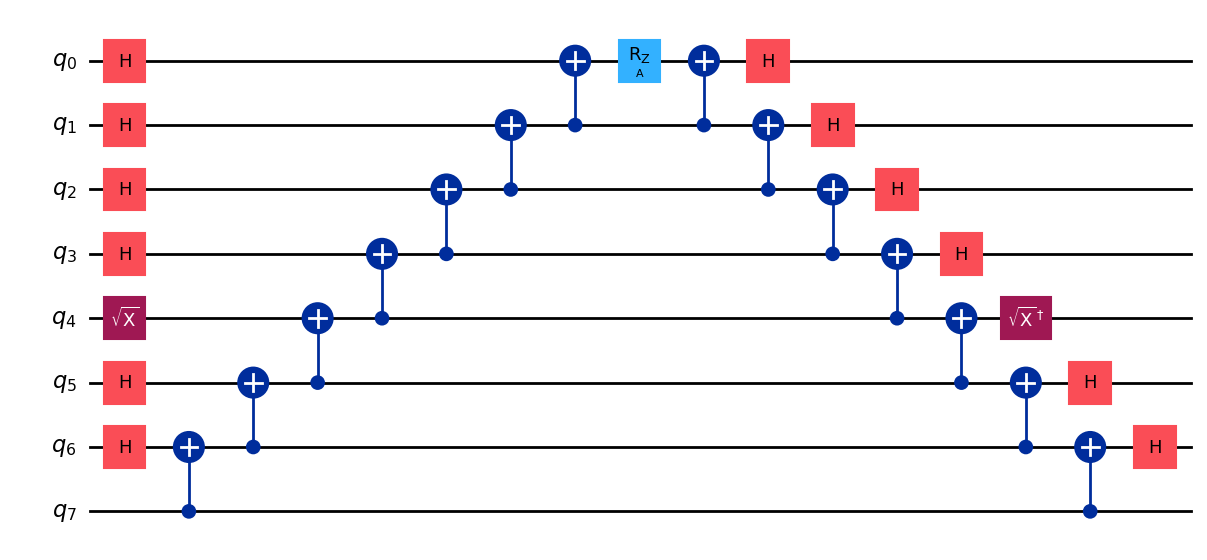

In [10]:
isa_qc.draw("mpl")

$R_{ZXXXYXXX}$
pauli_product_rotation


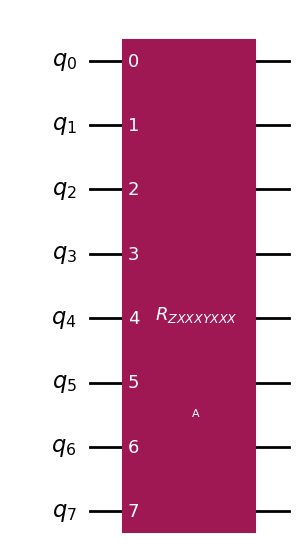

In [11]:
qc = QuantumCircuit(8)
test_gate = test.gate_pool[32832](Parameter("A"))
qc.append(test_gate,list(range(8)))
isa_qc = pm.run(qc)
print(test_gate.label)
print(test_gate.name)
qc.draw("mpl")

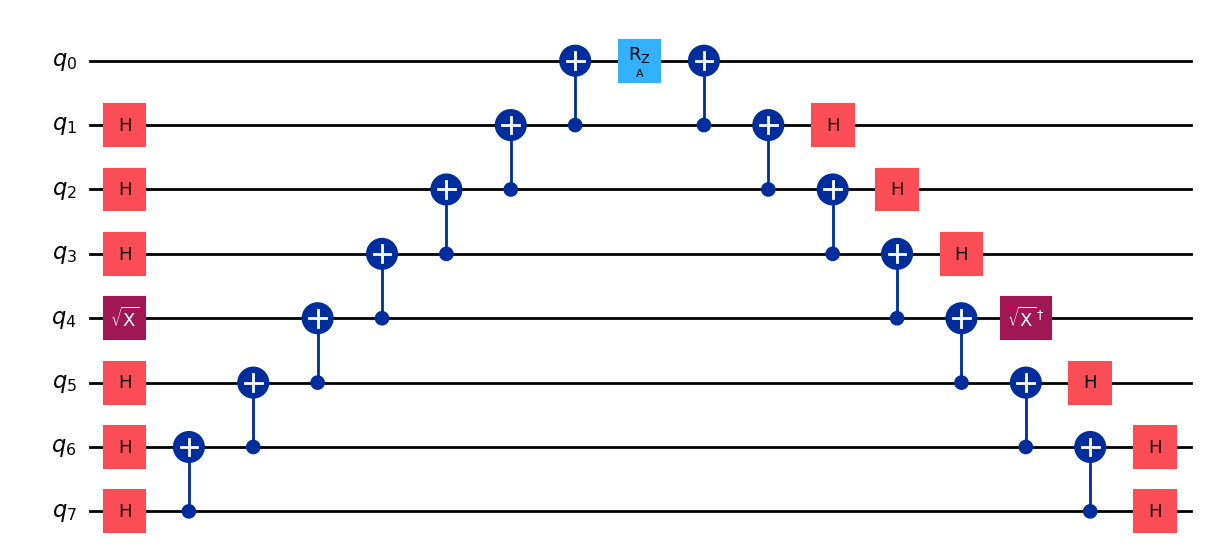

In [12]:
isa_qc.draw("mpl")

In [13]:
pauli_gates[4545].label

'$R_{YXXIYXYX}$'

In [14]:
pauli_gates[4545].validate_parameter(42)

42

In [15]:
test.operator_pool[-1].to_list()[0][0]

'ZIIIIIII'

In [1]:
from solver.circuits import HardwareAdaptAnsatz24

test = HardwareAdaptAnsatz24(8)

In [10]:
for i in range(300):
    print(test.operator_pool[i].to_list()[0][0], test.gate_pool[test.operator_gate_map[i][0]](42).label)

IIIIIIIX $R_{X}$
IIIIIIXI $R_{X}$
IIIIIXII $R_{X}$
IIIIXIII $R_{X}$
IIIXIIII $R_{X}$
IIXIIIII $R_{X}$
IXIIIIII $R_{X}$
XIIIIIII $R_{X}$
IIIIIIIY $R_{Y}$
IIIIIIYI $R_{Y}$
IIIIIYII $R_{Y}$
IIIIYIII $R_{Y}$
IIIYIIII $R_{Y}$
IIYIIIII $R_{Y}$
IYIIIIII $R_{Y}$
YIIIIIII $R_{Y}$
IIIIIIIZ $R_{Z}$
IIIIIIZI $R_{Z}$
IIIIIZII $R_{Z}$
IIIIZIII $R_{Z}$
IIIZIIII $R_{Z}$
IIZIIIII $R_{Z}$
IZIIIIII $R_{Z}$
ZIIIIIII $R_{Z}$
IIIIIIXX $R_{XX}$
IIIIIXXI $R_{XX}$
IIIIXXII $R_{XX}$
IIIXXIII $R_{XX}$
IIXXIIII $R_{XX}$
IXXIIIII $R_{XX}$
XXIIIIII $R_{XX}$
IIIIIIYX $R_{XY}$
IIIIIYXI $R_{XY}$
IIIIYXII $R_{XY}$
IIIYXIII $R_{XY}$
IIYXIIII $R_{XY}$
IYXIIIII $R_{XY}$
YXIIIIII $R_{XY}$
IIIIIIZX $R_{XZ}$
IIIIIZXI $R_{XZ}$
IIIIZXII $R_{XZ}$
IIIZXIII $R_{XZ}$
IIZXIIII $R_{XZ}$
IZXIIIII $R_{XZ}$
ZXIIIIII $R_{XZ}$
IIIIIIXY $R_{YX}$
IIIIIXYI $R_{YX}$
IIIIXYII $R_{YX}$
IIIXYIII $R_{YX}$
IIXYIIII $R_{YX}$
IXYIIIII $R_{YX}$
XYIIIIII $R_{YX}$
IIIIIIYY $R_{YY}$
IIIIIYYI $R_{YY}$
IIIIYYII $R_{YY}$
IIIYYIII $R_{YY}$
IIYYIIII $R_{YY}

In [11]:
len(test.operator_pool)

14748